In [1]:
import numpy as np
import jax
import matplotlib.pyplot as plt
from jaxstar import mistfit
from jax import random
import arviz, corner
import pandas as pd
jax.config.update("jax_platform_name", "cpu")

In [2]:
import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
plt.rcParams["figure.figsize"] = (12,6)
from matplotlib import rc

In [3]:
teff, kmag_obs, kmag_err, feh_obs, parallax_obs, parallax_err = [5322, 11.161, 0.026, 0.06, 3.3410, 0.01958]

In [4]:
def run(mf, teff_err=100, feh_err=0.05, save=None):
	mf.set_data(['teff','feh', 'kmag', 'parallax'],\
            [teff, feh_obs, kmag_obs, parallax_obs],\
            [teff_err, feh_err, kmag_err, parallax_err])
	# setup HMC
	ns = 20000
	mf.setup_hmc(num_warmup=ns, num_samples=ns)
	# run
	rng_key = random.PRNGKey(0)
	mf.run_hmc(rng_key, linear_age=True, flat_age_marginal=False, nodata=False)

	samples = mf.samples

	outkeys = mf.obskeys + ['mass', 'radius', 'age', 'eep']
	obsvals = mf.obsvals + [None] * 4

	params = np.array(pd.DataFrame(data=dict(zip(outkeys, [samples[k] for k in outkeys]))))
	fig = corner.corner(params, show_titles="%.2f", truths=obsvals, labels=outkeys)

	if save is not None:
		plt.savefig(save+".png", dpi=200, bbox_inches="tight")

	return samples

In [5]:
mf = mistfit.MistFit()

sample: 100%|██████████| 40000/40000 [01:03<00:00, 632.16it/s, 31 steps of size 3.85e-02. acc. prob=0.94] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
       age      4.87      3.10      4.42      0.11      9.38   1298.22      1.00
  distance      0.30      0.00      0.30      0.30      0.30   7686.18      1.00
       eep    332.39     25.38    337.01    294.80    377.93   1376.04      1.00
  feh_init      0.05      0.04      0.05     -0.02      0.13   6548.03      1.00

Number of divergences: 0


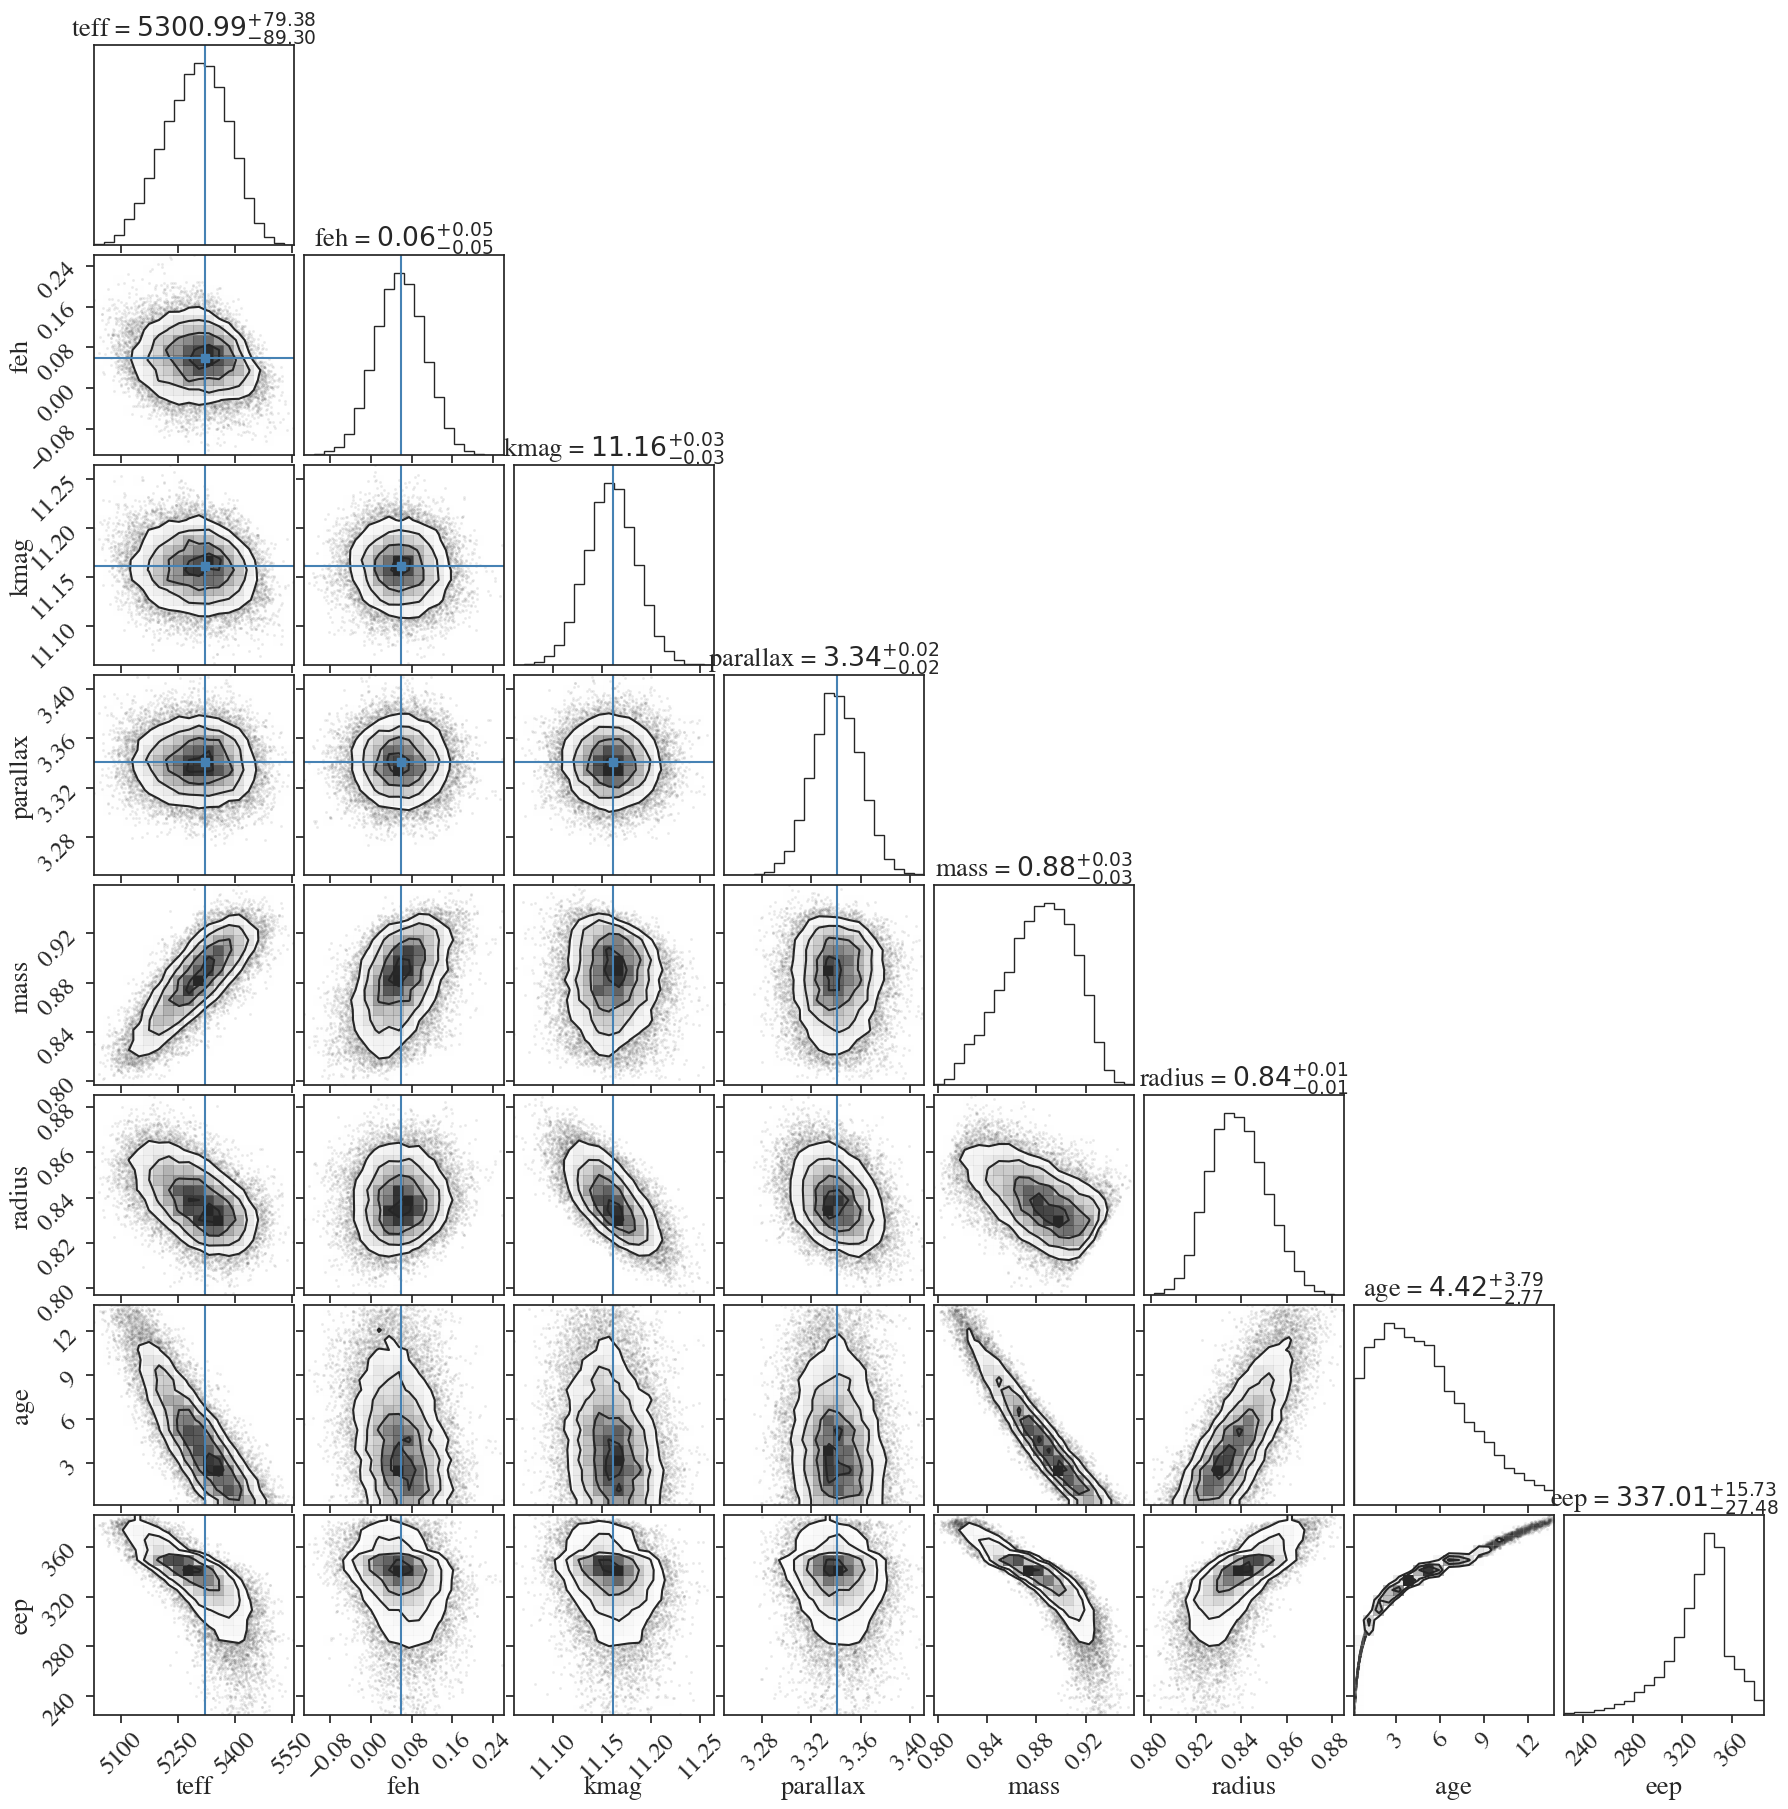

In [ ]:
smp = run(mf, save='jaxstar_corner')

In [17]:
logages = np.log10(np.linspace(0.05, 10., 2000) * 1e9)

In [18]:
def get_isochrone(mf, smp):
    feh = smp['feh'].mean()
    mass = smp['mass'].mean()
    logage = smp['logage'].mean()
    kmags, teffs = np.array([np.array(mf.mg.values_given_mass(logage, feh, mass))[:2] for logage in logages]).T
    return kmags, teffs, feh, mass, logage

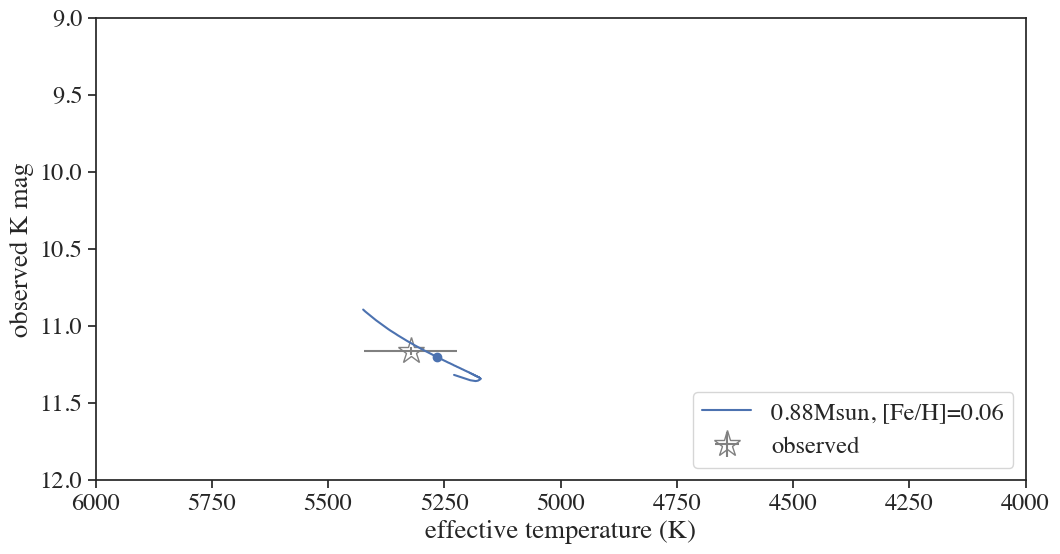

In [23]:
c = 10**logages / 1e9
dm = 5 * np.log10(parallax_obs) - 10
plt.figure(figsize=(12,6))
plt.ylim(12, 9)
plt.xlim(6000, 4000)
plt.ylabel("observed K mag")
plt.xlabel("effective temperature (K)")
kmags, teffs, feh, mass, logage = get_isochrone(mf, smp)
plt.plot(teffs, kmags-dm, color='C0', label=f'{mass:.2f}Msun, [Fe/H]={feh:.2f}')
idx = np.argmin(np.abs(logages-logage))
plt.plot(teffs[idx], kmags[idx]-dm, color='C0', marker='o')
plt.errorbar(teff, kmag_obs, xerr=100, yerr=kmag_err, fmt='*', markersize=20, mfc='none', color='gray', label='observed', mew=1, zorder=-1000)
plt.legend(loc='lower right')
plt.savefig("hr_comparison.png", dpi=200, bbox_inches="tight")